## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# Taller 5

# Librerías

In [30]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')

# Sobre diagramas y procesos a mano
Para todos los puntos de adjunta un archivo .pdf con diagramas y procesos a fines, para mayor claridad del proceso que se llevo acabo en cada ejercicio.

# ej1 
Las tres pequeñas esferas están soldadas al marco rígido liviano, el cual está girando
en un plano horizontal alrededor de un eje vertical que pasa por el punto O, con una
velocidad angular de 20 rad/s. A partir del instante t=0 se aplica un momento par
constante de 30Nm, grafique la velocidad angular durante los primeros 5 segundos del
movimiento.

In [31]:
t = symbols('t')
omega = dynamicsymbols('omega')
M, I, w0 = symbols('M I w0')

# Ecuación del momento angular neto
eq_motion = Eq(diff(omega, t), M/I)
display(eq_motion)


omega_t = integrate(eq_motion.rhs, t) + w0
display(Eq(omega, omega_t))

# Datos del problema
M_val = 30      # N·m
m1, m2, m3 = 4, 3, 3  # kg
r1, r2, r3 = 0.4, 0.5, 0.6  # m
w0_val = 20     # rad/s

# Cálculo del momento de inercia total
I_val = m1*r1**2 + m2*r2**2 + m3*r3**2
display(Eq(I, I_val))


    M
ω̇ = ─
    I

         M⋅t
ω = w₀ + ───
          I 

I = 2.47

In [32]:
omega_expr = simplify(omega_t.subs({M: M_val, I: I_val, w0: w0_val}))
display(Eq(omega, omega_expr))


ω = 12.1457489878543⋅t + 20

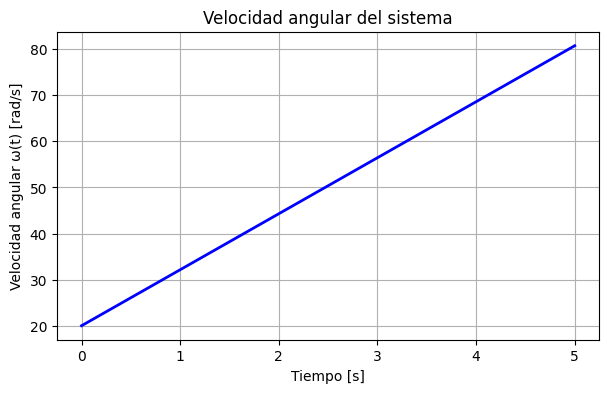

In [33]:
import numpy as np

# Tiempo (s)
t_vals = np.linspace(0, 5, 200)

# Función numérica
omega_func = lambda t: float(omega_expr.subs({'t': t}))
omega_vals = [omega_func(t) for t in t_vals]

# Gráfica
plt.figure(figsize=(7,4))
plt.plot(t_vals, omega_vals, color='b', lw=2)
plt.title('Velocidad angular del sistema')
plt.xlabel('Tiempo [s]')
plt.ylabel('Velocidad angular ω(t) [rad/s]')
plt.grid(True)
plt.show()


In [34]:
omega_5 = omega_expr.subs(t, 5)
display(Eq(omega.subs(t, 5), omega_5))
float(omega_5)

ω(5) = 80.7287449392713

80.72874493927125

# ej2
La barra AB de 4m de longitud, tiene una masa de 60kg y está pivotada en el baúl de
una camioneta pick-up, reforzada con un cable BC. Calcule la magnitud de la fuerza
sobre el cable cuando y la reacción en el pin A cuando la camioneta acelera a 5m/s
arrancando desde el reposo.

In [35]:
# Definimos simbolos por usar

T, Ra, Rax, Ray = symbols('T Ra Rax Ray', real=True)

# --- Parameters ---
L_val = 4
d_AC_val = 2
theta_val = 60 * pi/180
a_val = 5
m = 60
g = 9.81
# --- Frame and points ---
N = ReferenceFrame('N')
A = Point('A')
B = Point('B')
C = Point('C')
G = Point('G')

# Positions (bar up-left)
B.set_pos(A, L_val * (-cos(theta_val)*N.x + sin(theta_val)*N.y))
C.set_pos(A, d_AC_val * N.x)
G.set_pos(A, (L_val/2) * (-cos(theta_val)*N.x + sin(theta_val)*N.y))

## Aquí ChatGPT ayuda a ver si estamos definiendo la geometría correctamente, y le digo que haga un diagrama bonito del problema

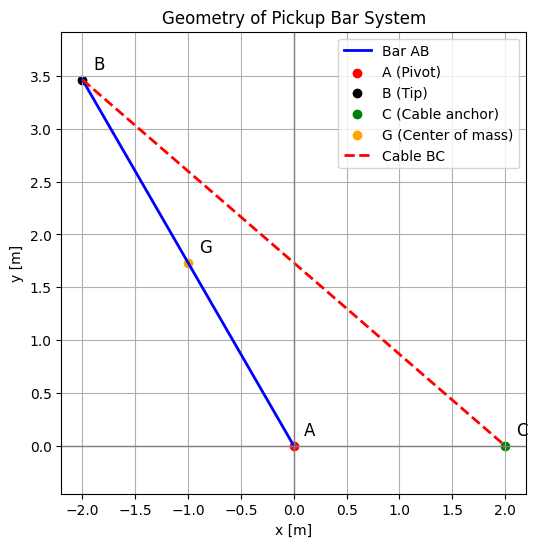

In [36]:
# --- Extract coordinates ---
def coords(P):
    """Return x,y coordinates of a point relative to A"""
    return float(P.pos_from(A).dot(N.x)), float(P.pos_from(A).dot(N.y))

A_xy = (0, 0)
B_xy = coords(B)
C_xy = coords(C)
G_xy = coords(G)

# --- Plot ---
plt.figure(figsize=(6,6))
plt.plot([A_xy[0], B_xy[0]], [A_xy[1], B_xy[1]], 'b-', lw=2, label='Bar AB')
plt.scatter(*A_xy, color='r', label='A (Pivot)')
plt.scatter(*B_xy, color='k', label='B (Tip)')
plt.scatter(*C_xy, color='g', label='C (Cable anchor)')
plt.scatter(*G_xy, color='orange', label='G (Center of mass)')

# Draw cable BC
plt.plot([B_xy[0], C_xy[0]], [B_xy[1], C_xy[1]], 'r--', lw=2, label='Cable BC')

# Annotate
for name, xy in zip(['A','B','C','G'], [A_xy,B_xy,C_xy,G_xy]):
    plt.text(xy[0]+0.1, xy[1]+0.1, name, fontsize=12)

plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.axis('equal')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Geometry of Pickup Bar System')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
# Creamos vectores de las posiciones 
r_AB = B.pos_from(A)
r_AG = G.pos_from(A)
r_BG = G.pos_from(B)
r_BC = C.pos_from(B)
r_BA = -r_AB

display(r_BG)

# Definimos un vector unitario para la dirección de la tensión BC
r_BC_mag = sqrt(r_BC.dot(r_BC))
u_BC = r_BC / r_BC_mag

# Fuerzas
W = -m*g*N.y
F_in = -m*a_val*N.x
T_vec = T * u_BC
Ra = Rax*N.x + Ray*N.y

# Hacemos momentos y despejamos T
M_A_W = cross(r_AG, W)
M_A_in = cross(r_AG, F_in)
M_A_T = cross(r_AB, T_vec)

display(M_A_W)
display(M_A_in)
display(M_A_T)

M_eq = (M_A_W + M_A_in + M_A_T).dot(N.z)
print("Ecuación escalar de momentos en A:")
print(M_eq.simplify())
display(M_eq)

# Despejar Tensión 
T_sol = solve(Eq(M_eq, 0), T)
display(T_sol)

print("\nRESULTADOS NUMÉRICOS:")
print(f"T = {T_sol[0]:.3f} N") 

T_val = T_sol[0]

1.0 n_x + -1.0⋅√3 n_y

588.6 n_z

300.0⋅√3 n_z

-2⋅√21⋅T     
───────── n_z
    7        

Ecuación escalar de momentos en A:
-0.285714285714286*sqrt(21)*T + 300.0*sqrt(3) + 588.6


  2⋅√21⋅T                   
- ─────── + 300.0⋅√3 + 588.6
     7                      

[846.413372334856]


RESULTADOS NUMÉRICOS:
T = 846.413 N


In [38]:
# Sumatoria de fuerzas en x e y
F_eq_x = Eq(Rax + T_vec.dot(N.x)+F_in.dot(N.x), 0)
F_eq_y = Eq(Ray + T_vec.dot(N.y) + W.dot(N.y) + F_in.dot(N.y), 0)

display(F_eq_x.subs(T, T_val).evalf())
display(F_eq_y.subs(T, T_val).evalf())

sol = solve([F_eq_x.subs(T, T_val).evalf(), F_eq_y.subs(T, T_val).evalf()], [Rax, Ray])

Ra = sol[Rax]*N.x + sol[Ray]*N.y

print(f"Reacción en A: Ra = {Ra.evalf()} N")

Ra_magnitude = sqrt(sol[Rax]**2 + sol[Ray]**2)
Ra_angle = atan2(sol[Ray], sol[Rax]) * 180/pi
print(f"Magnitud de Ra: {Ra_magnitude.evalf():.3f} N")
print(f"Dirección de Ra: {Ra_angle.evalf():.3f}° from x-axis")

Rax + 339.828368445014 = 0

Ray - 1142.70762113533 = 0

Reacción en A: Ra = - 339.828368445014*N.x + 1142.70762113533*N.y N
Magnitud de Ra: 1192.168 N
Dirección de Ra: 106.562° from x-axis


## ej3
La barra OA tiene una masa de 2kg y la barra AB tiene una masa de 5kg. Puede considerarlas
como barras delgadas para el cálculo de inercia. La barra OA se debe mover con una velocidad
angular omega_0 de 10deg/s.

A. Realice el diagrama de cuerpo libre, indicando las fuerzas o momentos dados por las
reacciones.

B. Escriba las ecuaciones de Newton-Euler para cada cuerpo del sistema. Puede
plantearlas para el instante mostrado (OA horizontal) pero recomendamos hacerlo
genérico, para cualquier ángulo posible.

C. Para el instante mostrado, encuentre el momento de entrada sobre la barra OA que
permitiría mover la barra con el omega_0 deseado.

D. Solucione el problema en otras situaciones de ángulo de la barra OA, cuando se mueve
desde la posición mostrada hasta 45° en la dirección de omega_0. Realice una gráfica
que muestre el momento de entrada respecto al ángulo de la barra OA

RESULTADOS NUMÉRICOS DEL SISTEMA DE BARRAS
Longitud BC = 0.3354 m
Momento de entrada M_O en θ = 0.00 rad, ω = 10°/s (0.174533 rad/s):
M_O = -0.000551 N·m


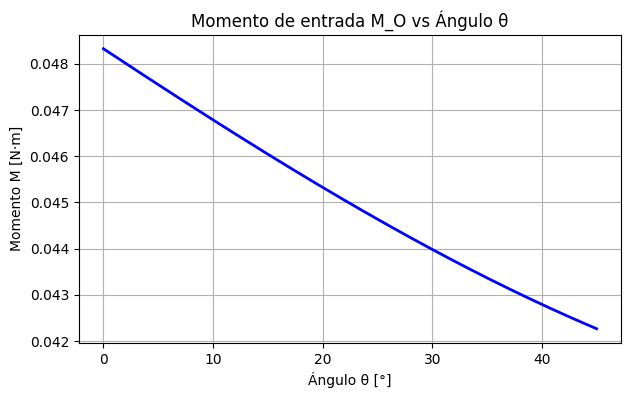

In [39]:

from sympy import lambdify


theta, theta_dot, theta_ddot = symbols('theta theta_dot theta_ddot', real=True)
m1, m2, L1, L2, OB = symbols('m1 m2 L1 L2 OB', positive=True)

Ax = L1 * cos(theta)
Ay = L1 * sin(theta)
Bx, By = 0, -OB

phi = atan2(Ay - By, Ax - Bx)

# Derivada de phi con respecto a theta
phi_theta = simplify(diff(phi, theta))
phi_dot = simplify(phi_theta * theta_dot)

# Longitud de la barra BC (puramente geométrica)
BC_len = simplify(sqrt((Ax - Bx)**2 + (Ay - By)**2))

# Momentos de las barras
I1 = (1/12) * m1 * L1**2
I2 = (1/12) * m2 * L2**2

# Posiciones de centros de masa
G1x = (L1/2) * cos(theta)
G1y = (L1/2) * sin(theta)
G2x = (Ax + Bx) / 2
G2y = (Ay + By) / 2

# Velocidades
G1vx = sp.diff(G1x, theta) * theta_dot
G1vy = sp.diff(G1y, theta) * theta_dot
G2vx = sp.diff(G2x, theta) * theta_dot
G2vy = sp.diff(G2y, theta) * theta_dot

# Momento angular
H1z = m1 * (G1x * G1vy - G1y * G1vx) + I1 * theta_dot
H2z = m2 * (G2x * G2vy - G2y * G2vx) + I2 * phi_dot
H_Oz = simplify(H1z + H2z)


M_O = simplify(diff(H_Oz, theta) * theta_dot + diff(H_Oz, theta_dot) * theta_ddot)
M_expr = simplify(M_O)

M_fun = lambdify(
    (theta, theta_dot, theta_ddot, m1, m2, L1, L2, OB),
    M_expr,
    modules=["numpy"]
)

BC_fun = lambdify((theta, L1, L2, OB), BC_len, "numpy")

# VALORES NUMÉRICOS
vals = {
    m1: 2.0,
    m2: 1.5,
    L1: 0.3,
    L2: 0.2,
    OB: 0.15
}

theta_val = 0.0
theta_dot_val = np.deg2rad(10.0)  # ω = 10°/s
theta_ddot_val = 0.0

# CÁLCULOS NUMÉRICOS
BC_value = BC_fun(theta_val, vals[L1], vals[L2], vals[OB])
M_value = M_fun(theta_val, theta_dot_val, theta_ddot_val,
                vals[m1], vals[m2], vals[L1], vals[L2], vals[OB])


print("RESULTADOS NUMÉRICOS DEL SISTEMA DE BARRAS")
print("===============================================")
print(f"Longitud BC = {BC_value:.4f} m")
print(f"Momento de entrada M_O en θ = {theta_val:.2f} rad, ω = 10°/s ({theta_dot_val:.6f} rad/s):")
print(f"M_O = {M_value:.6f} N·m")
print("===============================================")

thetas = np.linspace(0.0, 45.0 * np.pi / 180.0, 200)
M_vals = np.array([
    M_fun(th, theta_dot_val, 0.5,
          vals[m1], vals[m2], vals[L1], vals[L2], vals[OB])
    for th in thetas
], dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(thetas * 180 / np.pi, M_vals, 'b', linewidth=2)
plt.xlabel("Ángulo θ [°]")
plt.ylabel("Momento M [N·m]")
plt.title("Momento de entrada M_O vs Ángulo θ")
plt.grid(True)
plt.show()


## ej4
La barra uniforme AB de 15kg está sostenida sobre la superficie horizontal con un pequeño
rodillo de masa despreciable. El coeficiente de fricción cinético entre B y la superficie vertical
es 0.3. Calcule la aceleración inicial del extremo A cuando la barra se suelta desde el
reposo en posición mostrada.


In [40]:
# --- Símbolos ---
Ran, Rbn = sp.symbols('R_an R_bn', real=True)
m, L, g, mu = sp.symbols('m L g mu', positive=True)
theta, alpha = sp.symbols('theta alpha', real=True)

# --- Ecuaciones de movimiento ---
# Ecuación en X
eq_x = Eq(-Rbn, m * (L/2 * sin(theta) * alpha))

# Fuerza de fricción en B
fB = mu * Rbn

# Ecuación en Y
eq_y = Eq(Ran + fB - m*g, m * (L/2 * cos(theta) * alpha))

# Momento respecto a G
I_G = m * L**2 / 12
moment = Eq(I_G * alpha, -(L/2)*cos(theta)*Ran + (L/2)*(cos(theta)*fB + sin(theta)*Rbn))

# --- Resolución del sistema ---
sol = sp.solve([eq_x, eq_y, moment], [alpha, Ran, Rbn], dict=True)[0]

# --- Expresiones simbólicas ---
alpha_expr = simplify(sol[alpha])
aA_expr = simplify(L * sin(theta) * alpha_expr)

# --- Sustitución numérica ---
values = {
    m: 15.0,
    L: 2.4,
    g: 9.81,
    mu: 0.30
}

theta0 = 50.0 * pi/180.0

alpha_num = float(alpha_expr.subs({**values, theta: theta0}))
aA_num = float(aA_expr.subs({**values, theta: theta0}))

# --- Resultados ---
print("Resultados dinámicos de la barra:")
print("----------------------------------")
print(f"α (aceleración angular) = {alpha_num:.6f} rad/s²")
print(f"a_A (aceleración del punto A) = {aA_num:.6f} m/s²")
print("Dirección: hacia la izquierda (hacia la pared)")


Resultados dinámicos de la barra:
----------------------------------
α (aceleración angular) = -3.226220 rad/s²
a_A (aceleración del punto A) = -5.931427 m/s²
Dirección: hacia la izquierda (hacia la pared)


## Notas clase W10M2

In [41]:
import scipy

Text(0, 0.5, 'Position q1')

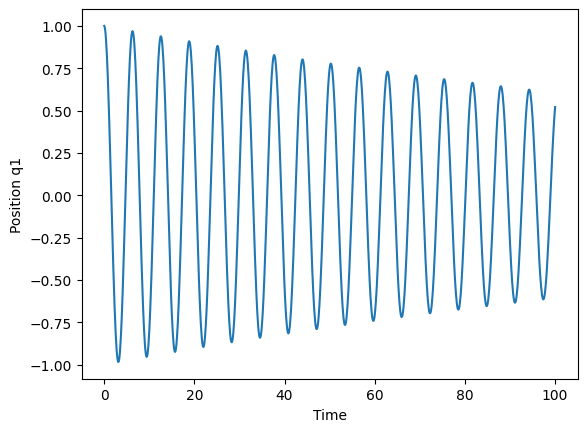

In [42]:
q1,q2= symbols('q1 q2')
def f(q, t):
    q1,q2=q
    k = 1
    m = 1.0
    c = 0.01
    qdot = [q2, -k*q1/m-c*q2/m]
    return qdot

tt = linspace(0,100,1000)

qq = scipy.integrate.odeint(f,[1,0],tt)

plt.plot(tt,qq[:,0])
plt.xlabel('Time')
plt.ylabel('Position q1')

In [43]:
scipy.integrate.odeint?

Signature:
scipy.integrate.odeint(
    func,
    y0,
    t,
    args=(),
    Dfun=None,
    col_deriv=0,
    full_output=0,
    ml=None,
    mu=None,
    rtol=None,
    atol=None,
    tcrit=None,
    h0=0.0,
    hmax=0.0,
    hmin=0.0,
    ixpr=0,
    mxstep=0,
    mxhnil=0,
    mxordn=12,
    mxords=5,
    printmessg=0,
    tfirst=False,
)
Docstring:
Integrate a system of ordinary differential equations.

.. note:: For new code, use `scipy.integrate.solve_ivp` to solve a
          differential equation.

Solve a system of ordinary differential equations using lsoda from the
FORTRAN library odepack.

Solves the initial value problem for stiff or non-stiff systems
of first order ode-s::

    dy/dt = func(y, t, ...)  [or func(t, y, ...)]

where y can be a vector.

.. note:: By default, the required order of the first two arguments of
          `func` are in the opposite order of the arguments in the system
          definition function used by the `scipy.integrate.ode` class and
        